In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# 80% = training, 20% = testing
train_df = pd.read_csv('/content/churn-bigml-80.csv')
test_df  = pd.read_csv('/content/churn-bigml-20.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
train_df.head()

Train shape: (2666, 20)
Test shape: (667, 20)

Columns: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
print("Train Info:")
train_df.info()
print("\nMissing values:", train_df.isnull().sum().sum())
print("\nChurn distribution:\n", train_df['Churn'].value_counts())

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666

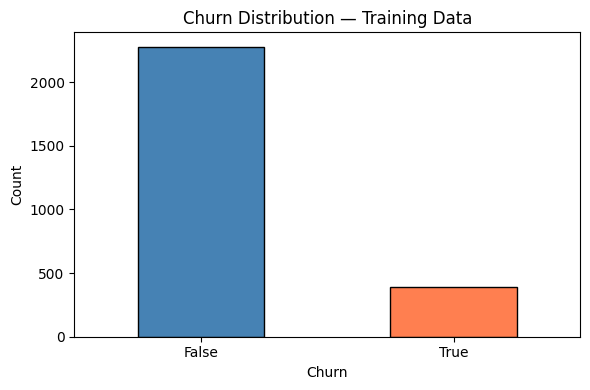

In [3]:
plt.figure(figsize=(6, 4))
train_df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Churn Distribution — Training Data')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

In [4]:
# Combine for consistent encoding
combined = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

# Encode boolean/categorical columns
le = LabelEncoder()
for col in combined.select_dtypes(include=['object', 'bool']).columns:
    combined[col] = le.fit_transform(combined[col].astype(str))

# Split back
train_clean = combined.iloc[:len(train_df)]
test_clean  = combined.iloc[len(train_df):]

# Features & Target
X_train = train_clean.drop(columns=['Churn'])
y_train = train_clean['Churn']

X_test = test_clean.drop(columns=['Churn'])
y_test = test_clean['Churn']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2666, 19)
X_test shape: (667, 19)


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled successfully!")

✅ Features scaled successfully!


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred)
    }
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy  : {results[name]['Accuracy']:.4f}")
    print(f"  Precision : {results[name]['Precision']:.4f}")
    print(f"  Recall    : {results[name]['Recall']:.4f}")
    print(f"  F1 Score  : {results[name]['F1 Score']:.4f}")


  Logistic Regression
  Accuracy  : 0.8531
  Precision : 0.4595
  Recall    : 0.1789
  F1 Score  : 0.2576

  Decision Tree
  Accuracy  : 0.9175
  Precision : 0.7041
  Recall    : 0.7263
  F1 Score  : 0.7150

  Random Forest
  Accuracy  : 0.9460
  Precision : 0.9538
  Recall    : 0.6526
  F1 Score  : 0.7750


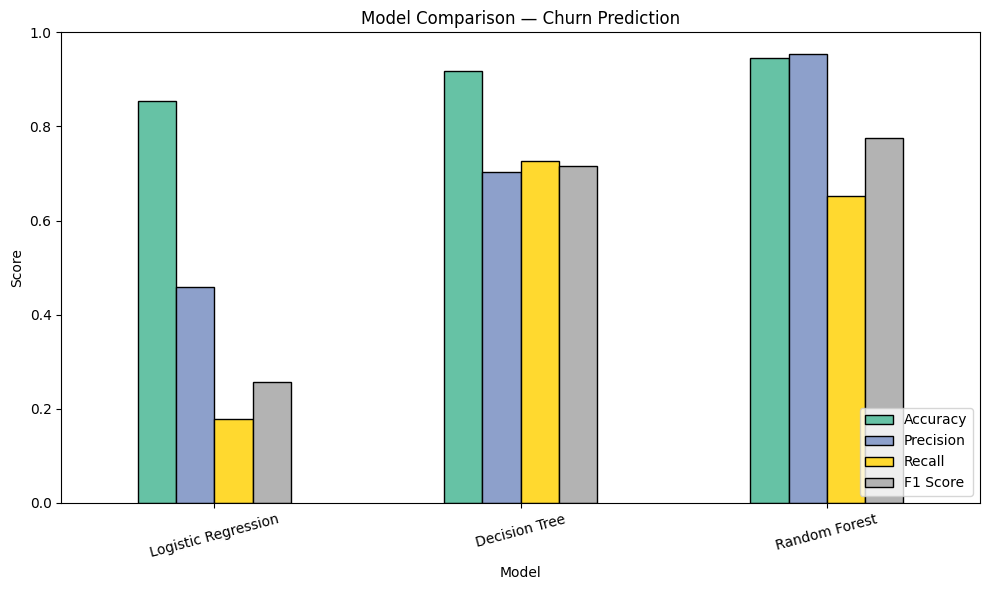

In [7]:
results_df = pd.DataFrame(results).T

results_df.plot(kind='bar', figsize=(10, 6), edgecolor='black', colormap='Set2')
plt.title('Model Comparison — Churn Prediction')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

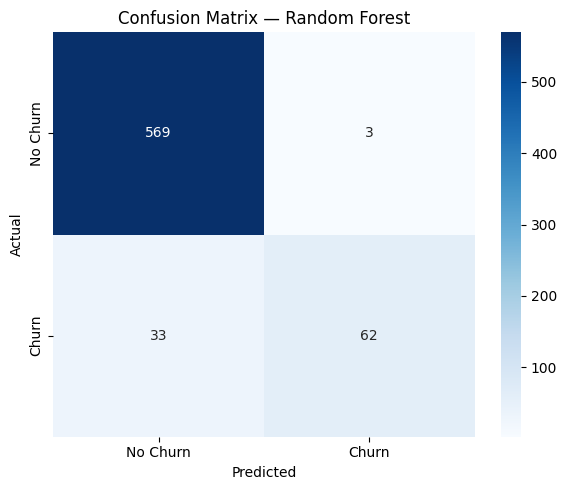


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97       572
       Churn       0.95      0.65      0.78        95

    accuracy                           0.95       667
   macro avg       0.95      0.82      0.87       667
weighted avg       0.95      0.95      0.94       667



In [8]:
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

/tmp/ipykernel_1593/460848379.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='coolwarm')


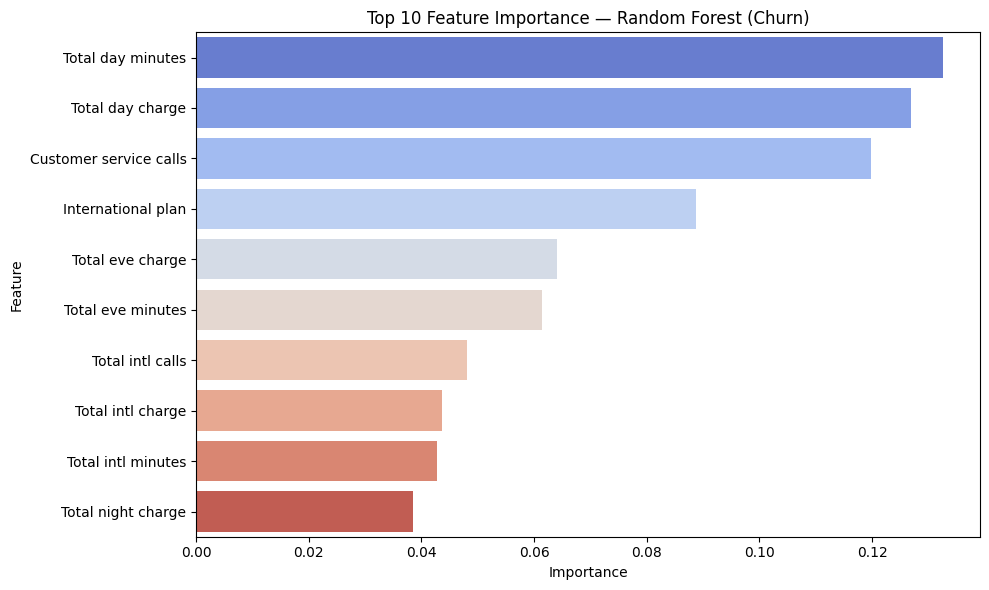

In [9]:
feat_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='coolwarm')
plt.title('Top 10 Feature Importance — Random Forest (Churn)')
plt.tight_layout()
plt.savefig('feature_importance_churn.png', dpi=150)
plt.show()

In [10]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best F1 Score:", round(grid_search.best_score_, 4))

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print(f"\nFinal Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Final F1 Score  : {f1_score(y_test, y_pred_best):.4f}")

✅ Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
✅ Best F1 Score: 0.8019

Final Accuracy  : 0.9535
Final F1 Score  : 0.8166


In [11]:
from google.colab import files

files.download('churn_distribution.png')
files.download('model_comparison.png')
files.download('confusion_matrix.png')
files.download('feature_importance_churn.png')
print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
